%%bash --bg
source /opt/ros/noetic/setup.bash
source ~/turtlebot3_ws/devel/setup.bash
roscore & sleep 3

%%bash --bg
source /opt/ros/noetic/setup.bash
source ~/turtlebot3_ws/devel/setup.bash
export TURTLEBOT3_MODEL=waffle
roslaunch turtlebot3_gazebo turtlebot3_world.launch use_sim_time:=true & sleep 5

%%bash --bg
source /opt/ros/noetic/setup.bash
source ~/turtlebot3_ws/devel/setup.bash
rosrun map_server map_server "$(rospack find turtlebot3_navigation)/maps/map.yaml" _use_sim_time:=true &

In [1]:
import rospy
import numpy as np
import matplotlib.pyplot as plt
import tf.transformations as tft
import math, time
from nav_msgs.msg import OccupancyGrid, Odometry
from sensor_msgs.msg import LaserScan
from geometry_msgs.msg import Twist
from IPython.display import clear_output, display

# --- Configuration ---
LIN_SPEED     = 0.15    # m/s forward speed
ANG_GAIN      = 1.5     # angular gain for heading correction
OBSTACLE_DIST = 0.5     # meters: threshold to trigger avoidance
RATE_HZ       = 10      # Hz control loop frequency

rospy.init_node('turtlebot3_enhanced_nav', anonymous=False)

In [2]:
class State:
    def __init__(self):
        self.map  = None
        self.odom = None
        self.scan = None
        self.trajectory = []

state = State()

rospy.Subscriber('/map', OccupancyGrid, lambda m: setattr(state, 'map', m), queue_size=1)
rospy.Subscriber('/odom', Odometry,     lambda m: setattr(state, 'odom', m), queue_size=1)
rospy.Subscriber('/scan', LaserScan,    lambda m: setattr(state, 'scan', m), queue_size=1)

print("Waiting for sensor data and map...")
while not state.map or not state.odom and not rospy.is_shutdown():
    rospy.sleep(0.1)
print("Sensors and Map Loaded Successfully!")

Waiting for sensor data and map...
Sensors and Map Loaded Successfully!


In [3]:
def world_to_grid(x, y, info):
    gx = int((x - info.origin.position.x) / info.resolution)
    gy = int((y - info.origin.position.y) / info.resolution)
    return gx, gy

def grid_to_world(gx, gy, info):
    x = info.origin.position.x + (gx + 0.5) * info.resolution
    y = info.origin.position.y + (gy + 0.5) * info.resolution
    return x, y

def is_line_free(p1, p2, map_msg):
    width, height = map_msg.info.width, map_msg.info.height
    x1, y1 = p1
    x2, y2 = p2
    dx, dy = abs(x2 - x1), abs(y2 - y1)
    sx, sy = (1 if x2 > x1 else -1), (1 if y2 > y1 else -1)
    err = dx - dy

    while True:
        if not (0 <= x1 < width and 0 <= y1 < height):
            return False
        if map_msg.data[y1 * width + x1] != 0:
            return False
        if (x1, y1) == (x2, y2):
            break
        e2 = 2 * err
        if e2 > -dy:
            err -= dy
            x1 += sx
        if e2 < dx:
            err += dx
            y1 += sy
    return True

In [4]:
def heuristic(a, b):
    return math.hypot(b[0] - a[0], b[1] - a[1])

def a_star(start, goal, map_msg):
    info = map_msg.info
    width, height = info.width, info.height
    occ = map_msg.data

    open_set = {start}
    came_from = {}
    g_score = {start: 0}
    f_score = {start: heuristic(start, goal)}

    while open_set:
        current = min(open_set, key=lambda p: f_score.get(p, float('inf')))
        if current == goal:
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            path.reverse()
            return path

        open_set.remove(current)
        for dx in [-1, 0, 1]:
            for dy in [-1, 0, 1]:
                if dx == 0 and dy == 0:
                    continue
                neighbor = (current[0] + dx, current[1] + dy)
                if not (0 <= neighbor[0] < width and 0 <= neighbor[1] < height):
                    continue
                idx = neighbor[1] * width + neighbor[0]
                if occ[idx] != 0:
                    continue
                tentative_g = g_score[current] + math.hypot(dx, dy)
                if neighbor not in g_score or tentative_g < g_score[neighbor]:
                    came_from[neighbor] = current
                    g_score[neighbor] = tentative_g
                    f_score[neighbor] = tentative_g + heuristic(neighbor, goal)
                    open_set.add(neighbor)
    return []

def smooth_path(path, map_msg):
    if not path:
        return []
    smoothed = [path[0]]
    i = 0
    while i < len(path) - 1:
        j = len(path) - 1
        while j > i + 1:
            if is_line_free(path[i], path[j], map_msg):
                break
            j -= 1
        smoothed.append(path[j])
        i = j
    return smoothed

In [5]:
info = state.map.info
w, h = info.width, info.height

# Set Start and Goal (Grid Coordinates)
start_g = (160, 190)
goal_g  = (190, 180)

# Validate limits
for name, (gx, gy) in [('Start', start_g), ('Goal', goal_g)]:
    if not (0 <= gx < w and 0 <= gy < h):
        raise ValueError(f"{name} out of bounds")
    idx = gy * w + gx
    if state.map.data[idx] != 0:
        raise ValueError(f"{name} cell is occupied")

# Calculate
raw_path = a_star(start_g, goal_g, state.map)
smoothed = smooth_path(raw_path, state.map)

print(f"Waypoints: raw={len(raw_path)}, smoothed={len(smoothed)}")

Waypoints: raw=31, smoothed=2


smoothed: [(160, 190), (190, 180)]


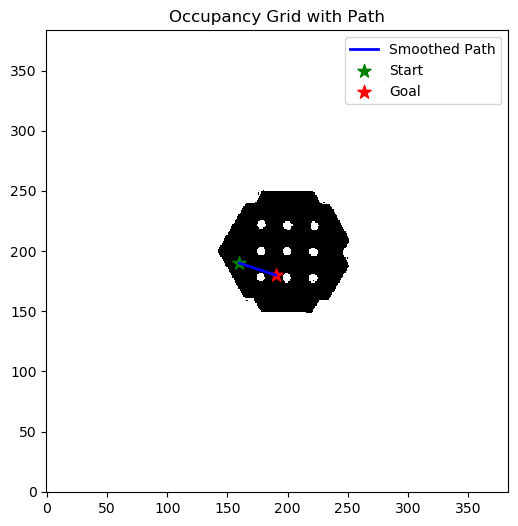

In [6]:
print("smoothed:", smoothed)

fig, ax = plt.subplots(figsize=(6,6))
grid = np.array(state.map.data).reshape((info.height, info.width))
ax.imshow((grid == 0).astype(int), origin='lower', cmap='gray_r')

if smoothed:
    sx, sy = zip(*smoothed)
    ax.plot(sx, sy, '-', linewidth=2, color='blue', label='Smoothed Path')
    ax.scatter(*start_g, color='green', marker='*', s=100, label='Start')
    ax.scatter(*goal_g, color='red',   marker='*', s=100, label='Goal')
    ax.legend()
else:
    ax.text(0.5, 0.5, "No path found", ha='center', va='center', transform=ax.transAxes)

plt.title("Occupancy Grid with Path")
plt.show()

In [7]:
vel_pub = rospy.Publisher('/cmd_vel', Twist, queue_size=1)
rate    = rospy.Rate(RATE_HZ)

def get_front_data(fov=90):
    if not state.scan:
        return np.array([]), np.array([])
    angles = state.scan.angle_min + np.arange(len(state.scan.ranges))*state.scan.angle_increment
    mask = (np.abs(angles) <= math.radians(fov))
    rs = np.array(state.scan.ranges)
    rs = np.where(np.isfinite(rs), rs, np.inf)
    return angles[mask], rs[mask]

def find_best_gap(angles, ranges, min_clear=0.6):
    clear = ranges > min_clear
    if not clear.any():
        return None
    segs = np.split(angles, np.where(~clear)[0])
    segs = [s for s in segs if s.size>0]
    best = max(segs, key=lambda s: s[-1]-s[0])
    return float((best[0]+best[-1])/2)

i = 0
stuck_timer = time.time()
print("Starting Robot Navigation...")

while not rospy.is_shutdown() and i < len(smoothed):
    pos = state.odom.pose.pose.position
    ori = state.odom.pose.pose.orientation
    yaw = tft.euler_from_quaternion([ori.x,ori.y,ori.z,ori.w])[2]

    gx, gy = smoothed[i]
    tx, ty = grid_to_world(gx, gy, info)
    dx, dy = tx-pos.x, ty-pos.y
    dist = math.hypot(dx,dy)
    desired = math.atan2(dy,dx)
    err_ang = (desired-yaw+math.pi)%(2*math.pi)-math.pi

    cmd = Twist()
    angs, rs = get_front_data(90)
    min_front = rs.min() if rs.size else np.inf

    if min_front < OBSTACLE_DIST:
        cmd.linear.x  = -0.05
        best = find_best_gap(angs, rs, min_clear=OBSTACLE_DIST)
        cmd.angular.z = (best if best is not None else 0.5)
        stuck_timer = time.time()
    else:
        if time.time() - stuck_timer < 0.5:
            pass
        else:
            if dist > 0.1:
                if abs(err_ang) > 0.3:
                    cmd.angular.z = 0.7 * math.copysign(1, err_ang)
                else:
                    cmd.linear.x  = LIN_SPEED
                    cmd.angular.z = ANG_GAIN * err_ang
            else:
                i += 1
                stuck_timer = time.time()

    vel_pub.publish(cmd)
    rate.sleep()

vel_pub.publish(Twist())
print("Navigation finished.")

Starting Robot Navigation...
Navigation finished.


In [ ]:
%%bash
rosnode kill -a
killall -9 roscore gzserver gzclient || true